In [34]:
import pandas as pd

In [35]:
train_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv')
test_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv')

In [36]:
train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [37]:
print(test_df.shape)
print(train_df.shape)

(220, 25)
(880, 25)


In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [39]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [40]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

knn_preds = knn.predict(x_test)
knn_accuracy = accuracy_score(y_test, knn_preds)

print("KNN Accuracy:", knn_accuracy)
print(classification_report(y_test, knn_preds))

KNN Accuracy: 0.8545454545454545
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        74
           1       0.82      0.93      0.87        72
           2       0.88      0.82      0.85        74

    accuracy                           0.85       220
   macro avg       0.86      0.86      0.85       220
weighted avg       0.86      0.85      0.85       220



In [41]:
feature_cols_pca = [c for c in train_df_pca.columns if c != "target"]

x_train_pca = train_df_pca[feature_cols_pca]
y_train_pca = train_df_pca["target"]

x_test_pca = test_df_pca[feature_cols_pca]
y_test_pca = test_df_pca["target"]

knn_pca = KNeighborsClassifier()
knn_pca.fit(x_train_pca, y_train_pca)

knn_preds_pca = knn_pca.predict(x_test_pca)
knn_accuracy_pca = accuracy_score(y_test_pca, knn_preds_pca)

knn_preds_pca_t = knn_pca.predict(x_train_pca) 
knn_accuracy_pca_train = accuracy_score(y_train_pca, knn_preds_pca_t)

print("KNN PCA Test Accuracy:", knn_accuracy_pca)
print("KNN PCA Training Accuracy:", knn_accuracy_pca_train)
print(classification_report(y_test_pca, knn_preds_pca))

KNN PCA Test Accuracy: 0.8727272727272727
KNN PCA Training Accuracy: 0.9159090909090909
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        74
           1       0.87      0.90      0.88        72
           2       0.88      0.86      0.87        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



In [42]:
#No overfitting or underfitting goin on

In [43]:
#PCA data perform way better there  for usinng PCA dataset

In [44]:
#Hyperparameter tuning KNN

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
knn_param_grid = {
    'n_neighbors': [3,5,7,9,11,13,15,17,19,21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'hamming']
}

In [47]:
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(x_train_pca, y_train_pca)

print("Best KNN parameters:", grid_knn.best_params_)
print("Best KNN CV accuracy:", grid_knn.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best KNN CV accuracy: 0.8931818181818182


In [48]:
best_knn = grid_knn.best_estimator_
tuned_knn_preds = best_knn.predict(x_test_pca)
tuned_knn_accuracy = accuracy_score(y_test_pca, tuned_knn_preds)

print("Tuned KNN Test Accuracy for Test Data:", tuned_knn_accuracy)
print(classification_report(y_test_pca, tuned_knn_preds))

tuned_knn_preds_t = best_knn.predict(x_train_pca)
tuned_knn_accuracy_t = accuracy_score(y_train_pca, tuned_knn_preds_t)

print("Tuned KNN Test Accuracy for Training Data:", tuned_knn_accuracy_t)
print(classification_report(y_train_pca, tuned_knn_preds_t))

Tuned KNN Test Accuracy for Test Data: 0.8772727272727273
              precision    recall  f1-score   support

           0       0.88      0.86      0.87        74
           1       0.88      0.90      0.89        72
           2       0.88      0.86      0.87        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220

Tuned KNN Test Accuracy for Training Data: 0.9181818181818182
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       299
           1       0.92      0.93      0.93       286
           2       0.90      0.92      0.91       295

    accuracy                           0.92       880
   macro avg       0.92      0.92      0.92       880
weighted avg       0.92      0.92      0.92       880



In [49]:
import joblib

joblib.dump(best_knn, "../results/model_trained_files/knn_model.pkl")

['../results/model_trained_files/knn_model.pkl']

In [50]:
#Visualizing

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay

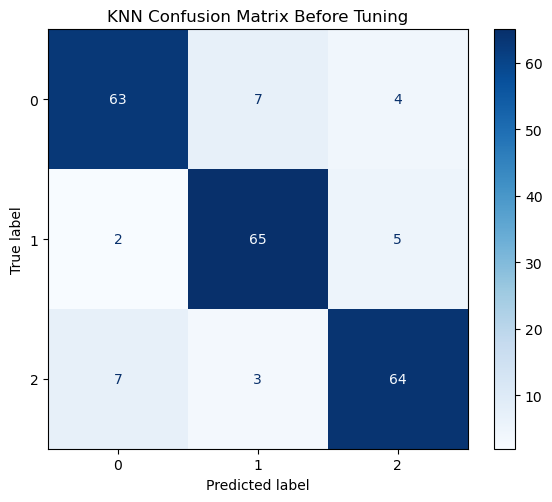

In [52]:
#Before tuning

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_pca,
    knn_preds_pca,
    cmap="Blues",
    ax=ax
)
ax.set_title("KNN Confusion Matrix Before Tuning")
plt.tight_layout()
plt.show()

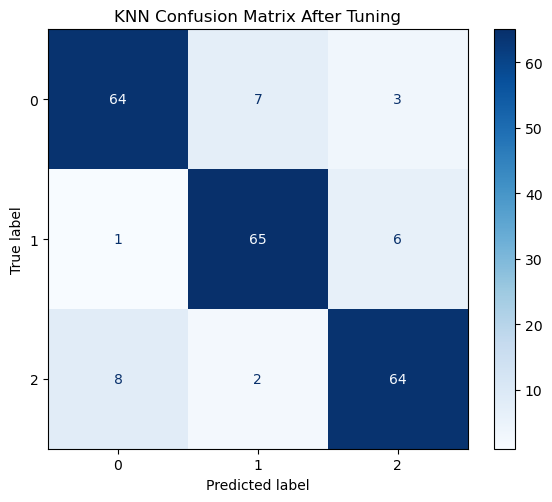

In [53]:
#After tuning

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_pca,
    tuned_knn_preds,
    cmap="Blues",
    ax=ax
)
ax.set_title("KNN Confusion Matrix After Tuning")
plt.tight_layout()
plt.show()